# Name: Ruturajsinh Udaysinh Vaghela
# Reg No: 24-27-07
# Programme: MTech Data Science
# Assignment Number: 3

# 1. MLE Using Normal Equation

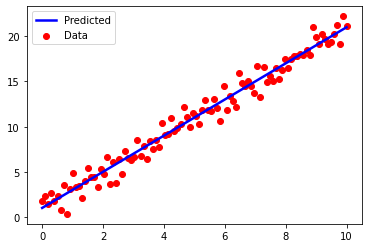

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def mle(x, y):
    X = np.vstack([np.ones(x.shape[0]), x]).T
    theta = np.dot(np.linalg.inv(np.dot(X.T, X)), np.dot(X.T, y))
    return theta

x = np.linspace(0, 10, 100)
y = 2 * x + 1 + np.random.normal(0, 1, x.shape)

theta = mle(x, y)

X = np.vstack([np.ones(x.shape[0]), x]).T
y_pred = np.dot(X, theta)

plt.scatter(x, y, label='Data', color='red')
plt.plot(x, y_pred, label='Predicted', color='blue', linewidth=2.5)
plt.legend()
plt.show()


# 2. Polynomial Regression

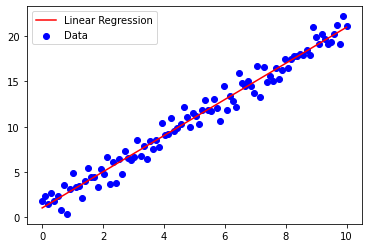

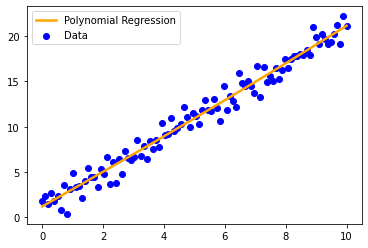

In [17]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x.reshape(-1, 1))

poly_reg_model = LinearRegression()
poly_reg_model.fit(x_poly, y)
y_poly_predict = poly_reg_model.predict(x_poly)

plt.scatter(x, y, label='Data', color='blue')
plt.plot(x, y_pred, label='Linear Regression', color='red')
plt.legend()
plt.show()

plt.scatter(x, y, label='Data', color='blue')
plt.plot(x, y_poly_predict, label='Polynomial Regression', color='orange', linewidth=2.5)
plt.legend()
plt.show()


# 3. Outlier Training With Linear Regression

# We can use the following methods for detecting outliers.

# 1. Z - Score Method:
Calculate the Z-score for each data point, which measures how many standard deviations an element is from the mean. <br>
A common threshold is 2 or 3 (points beyond this are considered outliers).

# 2. Interquartile Range (IQR) Method:
Calculate the first quartile (Q1) and the third quartile (Q3). <br>
Compute the IQR as IQR = Q3 − Q1. <br>
Define outliers as those points lying in the range <br>
Less than Q1 − 1.5 × IQR or Greater than Q3 + 1.5 × IQR. <br>

# 3. Visual Methods:
Use box plots or scatter plots to visually identify outliers.
        
# Using these 3 methods we can detect outlier. Once we know where the outliers are we can filter them out from the dataset and then perform linear regression

# Implementation using Z - Score:

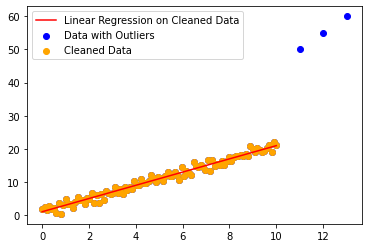

In [23]:
x_out = np.append(x, [11, 12, 13])
y_out = np.append(y, [50, 55, 60])

def zscore(x, y, threshold = 2):
    z_scores = np.abs((y - np.mean(y)) / np.std(y))
    return x[z_scores < threshold], y[z_scores < threshold]

x_clean, y_clean = zscore(x_out, y_out)

mle_clean = mle(x_clean, y_clean)
y_pred_2 = np.c_[np.ones((x_clean.shape[0], 1)), x_clean].dot(mle_clean)

plt.scatter(x_out, y_out, label='Data with Outliers', color='blue')
plt.scatter(x_clean, y_clean, label='Cleaned Data', color='orange')
plt.plot(x_clean, y_pred_2, label='Linear Regression on Cleaned Data', color='red')
plt.legend()
plt.show()


# https://github.com/Ruturaj18/Ruturaj_Vaghela_24-27-07.git